In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Connect to SQLite database
conn = sqlite3.connect("../data/bookings.db")

# Load bookings data
df = pd.read_sql_query("SELECT * FROM bookings", conn)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (64800, 7)


In [3]:
# Display first 5 rows
display(df.head())

# Dataset information
df.info()

,booking_id,timestamp,zone,service_type,rain_flag,providers_available,bookings
0,1,2026-01-01 00:00:00,Z1,cleaning,0,2,3
1,2,2026-01-01 00:00:00,Z1,laundry,0,3,2
2,3,2026-01-01 00:00:00,Z1,appliance,0,3,4
3,4,2026-01-01 00:00:00,Z2,cleaning,0,4,1
4,5,2026-01-01 00:00:00,Z2,laundry,0,4,6


<class 'pandas.DataFrame'>
RangeIndex: 64800 entries, 0 to 64799
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   booking_id           64800 non-null  int64
 1   timestamp            64800 non-null  str  
 2   zone                 64800 non-null  str  
 3   service_type         64800 non-null  str  
 4   rain_flag            64800 non-null  int64
 5   providers_available  64800 non-null  int64
 6   bookings             64800 non-null  int64
dtypes: int64(4), str(3)
memory usage: 3.5 MB


In [4]:
# Check missing values
print("Missing values:")
display(df.isnull().sum())

# Statistical summary
print("\nStatistical summary:")
display(df.describe(include="all"))

Missing values:


booking_id             0
timestamp              0
zone                   0
service_type           0
rain_flag              0
providers_available    0
bookings               0
dtype: int64


Statistical summary:


,booking_id,timestamp,zone,service_type,rain_flag,providers_available,bookings
count,64800.000000,64800,64800,64800,64800.000000,64800.000000,64800.000000
unique,NaN,4320,5,3,NaN,NaN,NaN
top,NaN,2026-01-01 00:00:00,Z1,cleaning,NaN,NaN,NaN
freq,NaN,15,12960,21600,NaN,NaN,NaN
mean,32400.500000,NaN,NaN,NaN,0.189120,3.478488,3.692361
std,18706.293059,NaN,NaN,NaN,0.391607,0.869553,2.404510
min,1.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000
25%,16200.750000,NaN,NaN,NaN,0.000000,3.000000,2.000000
50%,32400.500000,NaN,NaN,NaN,0.000000,3.000000,3.000000
75%,48600.250000,NaN,NaN,NaN,0.000000,4.000000,5.000000


In [5]:
# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

# Unique values in categorical columns
print("\nUnique zones:")
print(df["zone"].unique())

print("\nUnique service types:")
print(df["service_type"].unique())

# Target distribution
print("\nBookings distribution:")
print(df["bookings"].describe())

Duplicate rows: 0

Unique zones:
<StringArray>
['Z1', 'Z2', 'Z3', 'Z4', 'Z5']
Length: 5, dtype: str

Unique service types:
<StringArray>
['cleaning', 'laundry', 'appliance']
Length: 3, dtype: str

Bookings distribution:
count    64800.000000
mean         3.692361
std          2.404510
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         26.000000
Name: bookings, dtype: float64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [7]:
# Connect to SQLite database
conn = sqlite3.connect("../data/bookings.db")

# Load bookings data
df = pd.read_sql_query("SELECT * FROM bookings", conn)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (64800, 7)


In [8]:
# Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

print("\nUnique zones:")
print(df["zone"].unique())

print("\nUnique service types:")
print(df["service_type"].unique())

print("\nBookings distribution:")
print(df["bookings"].describe())

Duplicate rows: 0

Unique zones:
<StringArray>
['Z1', 'Z2', 'Z3', 'Z4', 'Z5']
Length: 5, dtype: str

Unique service types:
<StringArray>
['cleaning', 'laundry', 'appliance']
Length: 3, dtype: str

Bookings distribution:
count    64800.000000
mean         3.692361
std          2.404510
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         26.000000
Name: bookings, dtype: float64


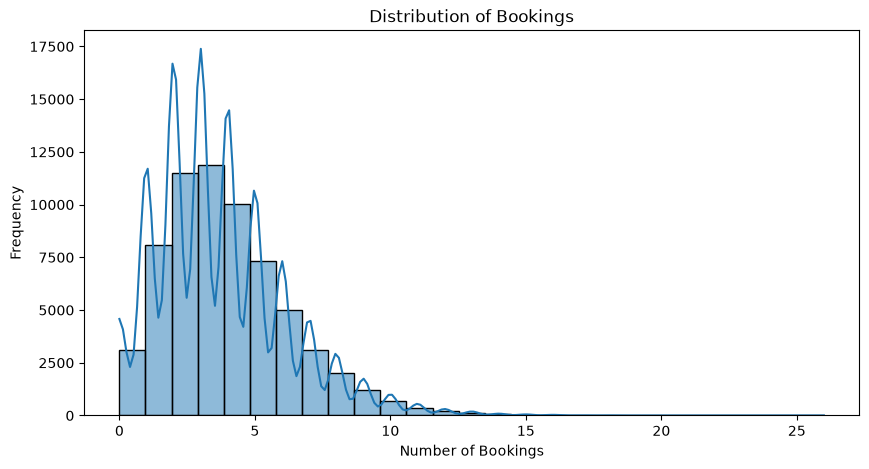

In [9]:
# Bookings distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["bookings"],
    bins=27,
    kde=True
)

plt.title("Distribution of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Frequency")

plt.show()

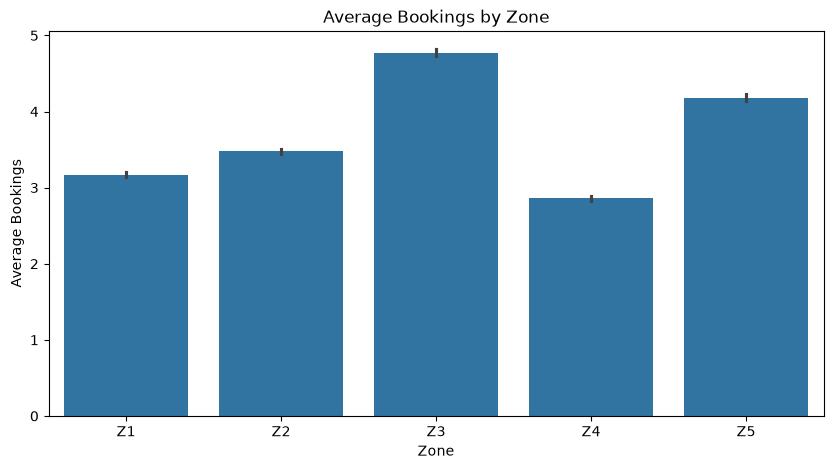

In [10]:
# Average bookings by zone

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="zone",
    y="bookings",
    estimator="mean"
)

plt.title("Average Bookings by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Bookings")

plt.show()

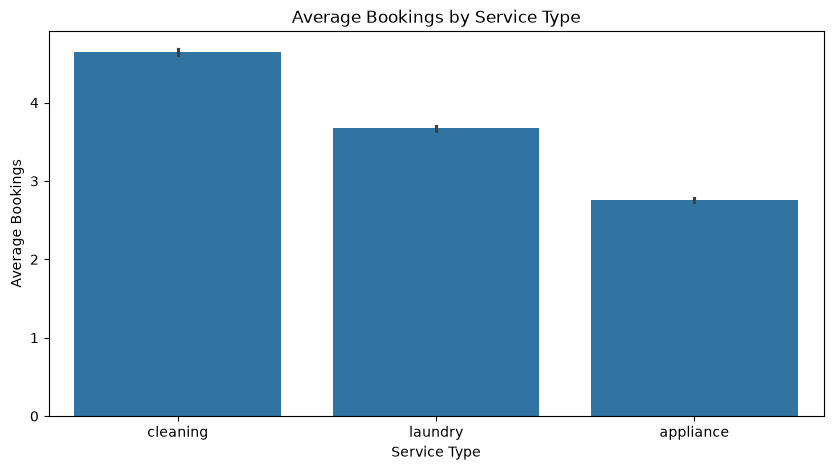

In [11]:
# Average bookings by service type

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="service_type",
    y="bookings",
    estimator="mean"
)

plt.title("Average Bookings by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Bookings")

plt.show()

In [12]:
# Convert timestamp to datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract time-based features

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.dayofweek

print(df[["timestamp", "year", "month", "day", "day_of_week"]].head())

   timestamp  year  month  day  day_of_week
0 2026-01-01  2026      1    1            3
1 2026-01-01  2026      1    1            3
2 2026-01-01  2026      1    1            3
3 2026-01-01  2026      1    1            3
4 2026-01-01  2026      1    1            3


In [13]:
# Analyze bookings based on rain flag

print("Average bookings by rain condition:")
display(
    df.groupby("rain_flag")["bookings"]
    .mean()
    .reset_index()
)

# Analyze bookings based on provider availability

print("\nAverage bookings by provider availability:")
display(
    df.groupby("providers_available")["bookings"]
    .mean()
    .reset_index()
)

# Average bookings by zone and service type

print("\nAverage bookings by zone and service type:")
display(
    df.groupby(["zone", "service_type"])["bookings"]
    .mean()
    .reset_index()
)

Average bookings by rain condition:


,rain_flag,bookings
0,0,3.575488
1,1,4.193472



Average bookings by provider availability:


,providers_available,bookings
0,1,2.859060
1,2,3.022834
2,3,3.283742
3,4,4.087995
4,5,4.611612
5,6,4.512422
6,7,7.000000



Average bookings by zone and service type:


,zone,service_type,bookings
0,Z1,appliance,2.359028
1,Z1,cleaning,3.991667
2,Z1,laundry,3.150694
3,Z2,appliance,2.633333
4,Z2,cleaning,4.308333
5,Z2,laundry,3.484491
6,Z3,appliance,3.523611
7,Z3,cleaning,6.022917
8,Z3,laundry,4.777083
9,Z4,appliance,2.155787


In [14]:
# Sort data chronologically for each zone and service

df = df.sort_values(
    ["zone", "service_type", "timestamp"]
).copy()

# Group data by zone and service type

grouped = df.groupby(["zone", "service_type"])["bookings"]

# Lag features

df["lag_1"] = grouped.shift(1)

df["lag_7"] = grouped.shift(7)

# Rolling average of previous 7 days

df["rolling_mean_7"] = (
    grouped.transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

# Remove rows with missing lag values

df = df.dropna().reset_index(drop=True)

print("Feature engineering completed!")

print("New dataset shape:", df.shape)

display(df.head(10))

Feature engineering completed!
New dataset shape: (64695, 14)


,booking_id,timestamp,zone,service_type,rain_flag,providers_available,bookings,year,month,day,day_of_week,lag_1,lag_7,rolling_mean_7
0,108,2026-01-01 07:00:00,Z1,appliance,1,3,1,2026,1,1,3,2.0,4.0,2.285714
1,123,2026-01-01 08:00:00,Z1,appliance,0,3,0,2026,1,1,3,1.0,1.0,1.857143
2,138,2026-01-01 09:00:00,Z1,appliance,0,3,3,2026,1,1,3,0.0,2.0,1.714286
3,153,2026-01-01 10:00:00,Z1,appliance,0,2,0,2026,1,1,3,3.0,5.0,1.857143
4,168,2026-01-01 11:00:00,Z1,appliance,0,3,2,2026,1,1,3,0.0,1.0,1.142857
5,183,2026-01-01 12:00:00,Z1,appliance,0,2,3,2026,1,1,3,2.0,1.0,1.285714
6,198,2026-01-01 13:00:00,Z1,appliance,0,4,2,2026,1,1,3,3.0,2.0,1.571429
7,213,2026-01-01 14:00:00,Z1,appliance,1,2,2,2026,1,1,3,2.0,1.0,1.571429
8,228,2026-01-01 15:00:00,Z1,appliance,0,3,3,2026,1,1,3,2.0,0.0,1.714286
9,243,2026-01-01 16:00:00,Z1,appliance,0,3,1,2026,1,1,3,3.0,3.0,2.142857


In [15]:
# Sort data by timestamp

df = df.sort_values("timestamp").reset_index(drop=True)

# Find the 80% time-based cutoff

unique_dates = df["timestamp"].sort_values().unique()

split_index = int(len(unique_dates) * 0.8)

split_date = unique_dates[split_index]

# Split into training and testing data

train_df = df[df["timestamp"] < split_date].copy()

test_df = df[df["timestamp"] >= split_date].copy()

print("Split date:", split_date)

print("Training data shape:", train_df.shape)

print("Testing data shape:", test_df.shape)

print("\nTraining date range:")
print(train_df["timestamp"].min(), "to", train_df["timestamp"].max())

print("\nTesting date range:")
print(test_df["timestamp"].min(), "to", test_df["timestamp"].max())

Split date: 2026-05-25 01:00:00
Training data shape: (51750, 14)
Testing data shape: (12945, 14)

Training date range:
2026-01-01 07:00:00 to 2026-05-25 00:00:00

Testing date range:
2026-05-25 01:00:00 to 2026-06-29 23:00:00


In [16]:
# Sort data chronologically within each zone and service

df = df.sort_values(
    ["zone", "service_type", "timestamp"]
).copy()

# Group by zone and service type

grouped = df.groupby(
    ["zone", "service_type"]
)["bookings"]

# Previous hour

df["lag_1h"] = grouped.shift(1)

# Previous day (24 hours)

df["lag_24h"] = grouped.shift(24)

# Previous week (168 hours)

df["lag_168h"] = grouped.shift(168)

# Rolling average of previous 24 hours

df["rolling_mean_24h"] = (
    grouped.transform(
        lambda x: x.shift(1).rolling(24).mean()
    )
)

# Remove rows with missing feature values

df = df.dropna().reset_index(drop=True)

print("Feature engineering completed!")

print("New dataset shape:", df.shape)

display(df.head(10))

Feature engineering completed!
New dataset shape: (62175, 18)


,booking_id,timestamp,zone,service_type,rain_flag,providers_available,bookings,year,month,day,day_of_week,lag_1,lag_7,rolling_mean_7,lag_1h,lag_24h,lag_168h,rolling_mean_24h
0,2628,2026-01-08 07:00:00,Z1,appliance,0,3,1,2026,1,8,3,3.0,2.0,1.857143,3.0,2.0,1.0,2.166667
1,2643,2026-01-08 08:00:00,Z1,appliance,0,3,6,2026,1,8,3,1.0,1.0,1.714286,1.0,3.0,0.0,2.125000
2,2658,2026-01-08 09:00:00,Z1,appliance,0,3,3,2026,1,8,3,6.0,2.0,2.428571,6.0,3.0,3.0,2.250000
3,2673,2026-01-08 10:00:00,Z1,appliance,1,3,1,2026,1,8,3,3.0,1.0,2.571429,3.0,1.0,0.0,2.250000
4,2688,2026-01-08 11:00:00,Z1,appliance,0,3,1,2026,1,8,3,1.0,2.0,2.571429,1.0,3.0,2.0,2.250000
5,2703,2026-01-08 12:00:00,Z1,appliance,0,3,0,2026,1,8,3,1.0,2.0,2.428571,1.0,1.0,3.0,2.166667
6,2718,2026-01-08 13:00:00,Z1,appliance,0,3,3,2026,1,8,3,0.0,3.0,2.142857,0.0,2.0,2.0,2.125000
7,2733,2026-01-08 14:00:00,Z1,appliance,0,3,2,2026,1,8,3,3.0,1.0,2.142857,3.0,0.0,2.0,2.166667
8,2748,2026-01-08 15:00:00,Z1,appliance,0,3,1,2026,1,8,3,2.0,6.0,2.285714,2.0,2.0,3.0,2.250000
9,2763,2026-01-08 16:00:00,Z1,appliance,0,3,2,2026,1,8,3,1.0,3.0,1.571429,1.0,0.0,1.0,2.208333


In [17]:
# Sort data by timestamp

df = df.sort_values("timestamp").reset_index(drop=True)

# Find the 80% time-based cutoff

unique_dates = df["timestamp"].sort_values().unique()

split_index = int(len(unique_dates) * 0.8)

split_date = unique_dates[split_index]

# Split into training and testing data

train_df = df[df["timestamp"] < split_date].copy()

test_df = df[df["timestamp"] >= split_date].copy()

print("Split date:", split_date)

print("Training data shape:", train_df.shape)

print("Testing data shape:", test_df.shape)

print("\nTraining date range:")
print(train_df["timestamp"].min(), "to", train_df["timestamp"].max())

print("\nTesting date range:")
print(test_df["timestamp"].min(), "to", test_df["timestamp"].max())

Split date: 2026-05-26 11:00:00
Training data shape: (49740, 18)
Testing data shape: (12435, 18)

Training date range:
2026-01-08 07:00:00 to 2026-05-26 10:00:00

Testing date range:
2026-05-26 11:00:00 to 2026-06-29 23:00:00


In [18]:
# Check all feature columns

print("All columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

All columns:
['booking_id', 'timestamp', 'zone', 'service_type', 'rain_flag', 'providers_available', 'bookings', 'year', 'month', 'day', 'day_of_week', 'lag_1', 'lag_7', 'rolling_mean_7', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h']

Dataset shape:
(62175, 18)

Missing values:
booking_id             0
timestamp              0
zone                   0
service_type           0
rain_flag              0
providers_available    0
bookings               0
year                   0
month                  0
day                    0
day_of_week            0
lag_1                  0
lag_7                  0
rolling_mean_7         0
lag_1h                 0
lag_24h                0
lag_168h               0
rolling_mean_24h       0
dtype: int64


In [19]:
# Prepare features and target

feature_columns = [
    "zone",
    "service_type",
    "rain_flag",
    "providers_available",
    "year",
    "month",
    "day",
    "day_of_week",
    "lag_1h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_24h"
]

X = df[feature_columns].copy()
y = df["bookings"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (62175, 12)
Target shape: (62175,)


,zone,service_type,rain_flag,providers_available,year,month,day,day_of_week,lag_1h,lag_24h,lag_168h,rolling_mean_24h
0,Z1,appliance,0,3,2026,1,8,3,3.0,2.0,1.0,2.166667
1,Z1,laundry,0,3,2026,1,8,3,1.0,1.0,5.0,2.666667
2,Z2,laundry,0,3,2026,1,8,3,1.0,1.0,0.0,3.083333
3,Z4,cleaning,0,3,2026,1,8,3,1.0,1.0,3.0,2.791667
4,Z2,cleaning,0,3,2026,1,8,3,4.0,1.0,3.0,3.541667


0    1
1    4
2    4
3    1
4    5
Name: bookings, dtype: int64

In [20]:
# Prepare train and test features

X_train = train_df[feature_columns].copy()
y_train = train_df["bookings"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["bookings"].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49740, 12)
X_test shape: (12435, 12)
y_train shape: (49740,)
y_test shape: (12435,)


In [21]:
# One-hot encode categorical features

X_train_encoded = pd.get_dummies(
    X_train,
    columns=["zone", "service_type"],
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=["zone", "service_type"],
    dtype=int
)

# Ensure both datasets have identical columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

display(X_train_encoded.head())

Encoded train shape: (49740, 18)
Encoded test shape: (12435, 18)


,rain_flag,providers_available,year,month,day,day_of_week,lag_1h,lag_24h,lag_168h,rolling_mean_24h,zone_Z1,zone_Z2,zone_Z3,zone_Z4,zone_Z5,service_type_appliance,service_type_cleaning,service_type_laundry
0,0,3,2026,1,8,3,3.0,2.0,1.0,2.166667,1,0,0,0,0,1,0,0
1,0,3,2026,1,8,3,1.0,1.0,5.0,2.666667,1,0,0,0,0,0,0,1
2,0,3,2026,1,8,3,1.0,1.0,0.0,3.083333,0,1,0,0,0,0,0,1
3,0,3,2026,1,8,3,1.0,1.0,3.0,2.791667,0,0,0,1,0,0,1,0
4,0,3,2026,1,8,3,4.0,1.0,3.0,3.541667,0,1,0,0,0,0,1,0


In [22]:
# Prepare data for Prophet

prophet_df = (
    df.groupby("timestamp", as_index=False)["bookings"]
    .sum()
    .rename(columns={
        "timestamp": "ds",
        "bookings": "y"
    })
    .sort_values("ds")
)

print("Prophet dataset shape:", prophet_df.shape)

display(prophet_df.head())

print("\nDate range:")
print(prophet_df["ds"].min(), "to", prophet_df["ds"].max())

Prophet dataset shape: (4145, 2)


,ds,y
0,2026-01-08 07:00:00,47
1,2026-01-08 08:00:00,49
2,2026-01-08 09:00:00,39
3,2026-01-08 10:00:00,50
4,2026-01-08 11:00:00,38



Date range:
2026-01-08 07:00:00 to 2026-06-29 23:00:00


In [23]:
# Train-test split for Prophet

split_index = int(len(prophet_df) * 0.8)

split_date = prophet_df.iloc[split_index]["ds"]

prophet_train = prophet_df[
    prophet_df["ds"] < split_date
].copy()

prophet_test = prophet_df[
    prophet_df["ds"] >= split_date
].copy()

print("Split date:", split_date)

print("Training shape:", prophet_train.shape)
print("Testing shape:", prophet_test.shape)

print("\nTraining date range:")
print(
    prophet_train["ds"].min(),
    "to",
    prophet_train["ds"].max()
)

print("\nTesting date range:")
print(
    prophet_test["ds"].min(),
    "to",
    prophet_test["ds"].max()
)

Split date: 2026-05-26 11:00:00
Training shape: (3316, 2)
Testing shape: (829, 2)

Training date range:
2026-01-08 07:00:00 to 2026-05-26 10:00:00

Testing date range:
2026-05-26 11:00:00 to 2026-06-29 23:00:00


In [24]:
from prophet import Prophet

# Create Prophet model

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

# Train the model

model.fit(prophet_train)

print("Prophet model trained successfully!")

Importing plotly failed. Interactive plots will not work.
16:17:39 - cmdstanpy - INFO - Chain [1] start processing
16:17:39 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [25]:
# Generate predictions for the test period

forecast = model.predict(prophet_test[["ds"]])

predictions = forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]]

print("Predictions generated!")

display(predictions.head())

Predictions generated!


,ds,yhat,yhat_lower,yhat_upper
0,2026-05-26 11:00:00,47.367384,35.233870,59.509450
1,2026-05-26 12:00:00,47.447702,34.981093,59.049836
2,2026-05-26 13:00:00,46.290679,34.149456,58.799919
3,2026-05-26 14:00:00,45.177405,33.203059,57.362539
4,2026-05-26 15:00:00,47.140295,34.828974,58.404694


In [26]:
# Evaluate Prophet predictions

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Merge actual test values with predictions
evaluation_df = prophet_test.merge(
    predictions,
    on="ds",
    how="left"
)

# Actual and predicted values
y_actual = evaluation_df["y"]
y_pred = evaluation_df["yhat"]

# Evaluation metrics
mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

# Avoid division by zero in MAPE
non_zero_mask = y_actual != 0

mape = np.mean(
    np.abs(
        (y_actual[non_zero_mask] - y_pred[non_zero_mask])
        / y_actual[non_zero_mask]
    )
) * 100

print("Prophet Model Evaluation")
print("-" * 30)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Prophet Model Evaluation
------------------------------
MAE: 7.69
RMSE: 10.09
MAPE: 13.62%


In [27]:
# Evaluate Prophet predictions

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Merge actual test values with predictions
evaluation_df = prophet_test.merge(
    predictions,
    on="ds",
    how="left"
)

# Actual and predicted values
y_actual = evaluation_df["y"]
y_pred = evaluation_df["yhat"]

# Evaluation metrics
mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

# Avoid division by zero in MAPE
non_zero_mask = y_actual != 0

mape = np.mean(
    np.abs(
        (y_actual[non_zero_mask] - y_pred[non_zero_mask])
        / y_actual[non_zero_mask]
    )
) * 100

print("Prophet Model Evaluation")
print("-" * 30)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Prophet Model Evaluation
------------------------------
MAE: 7.69
RMSE: 10.09
MAPE: 13.62%


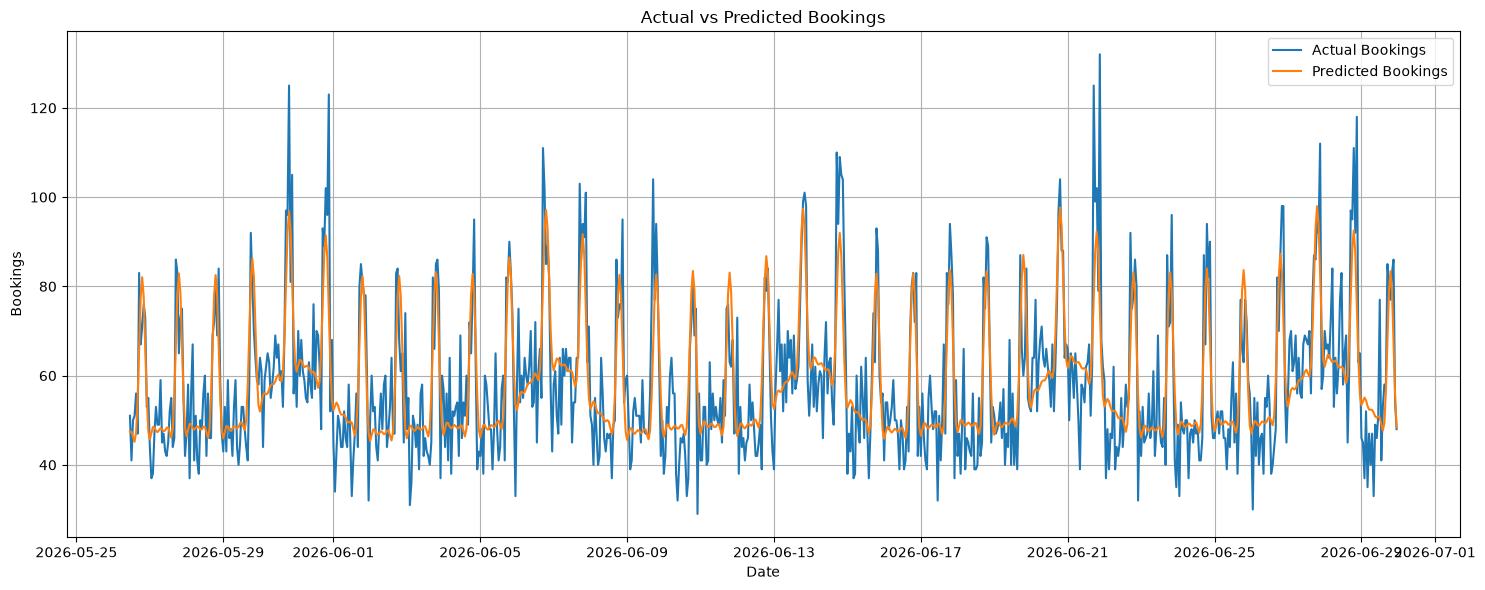

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    evaluation_df["ds"],
    evaluation_df["y"],
    label="Actual Bookings"
)

plt.plot(
    evaluation_df["ds"],
    evaluation_df["yhat"],
    label="Predicted Bookings"
)

plt.title("Actual vs Predicted Bookings")

plt.xlabel("Date")
plt.ylabel("Bookings")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Prophet Residual Analysis

evaluation_df = prophet_test.merge(
    predictions[["ds", "yhat"]],
    on="ds",
    how="inner"
)

evaluation_df["error"] = (
    evaluation_df["y"] - evaluation_df["yhat"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["error"].abs()
)

print("Mean Error:", evaluation_df["error"].mean())
print("Maximum Absolute Error:",
      evaluation_df["absolute_error"].max())

display(evaluation_df.head())

Mean Error: 0.35347543109021007
Maximum Absolute Error: 56.20231570145708


,ds,y,yhat,error,absolute_error
0,2026-05-26 11:00:00,51,47.367384,3.632616,3.632616
1,2026-05-26 12:00:00,41,47.447702,-6.447702,6.447702
2,2026-05-26 13:00:00,50,46.290679,3.709321,3.709321
3,2026-05-26 14:00:00,51,45.177405,5.822595,5.822595
4,2026-05-26 15:00:00,56,47.140295,8.859705,8.859705


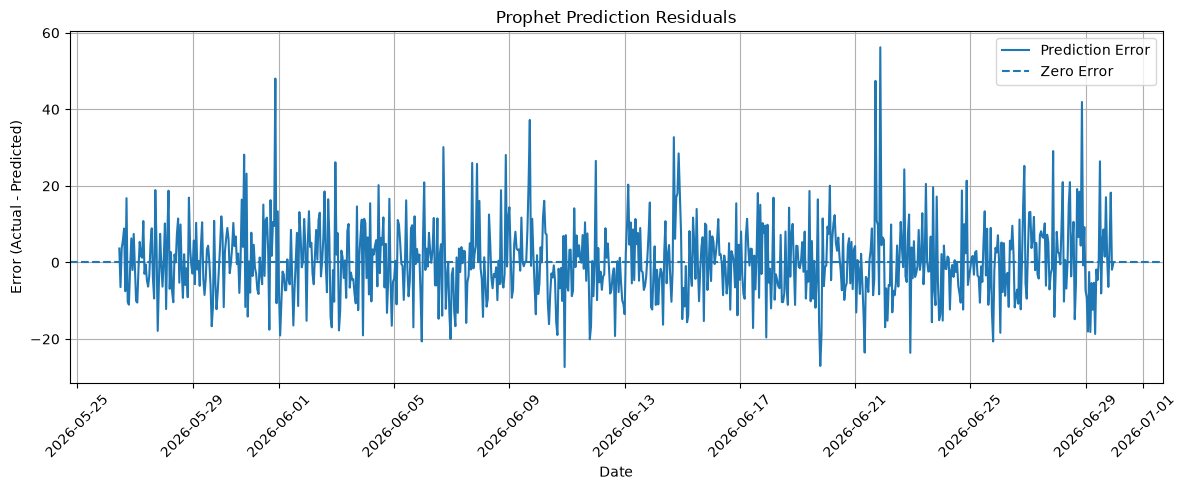

In [31]:
# Residual Analysis Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    evaluation_df["ds"],
    evaluation_df["error"],
    label="Prediction Error"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Zero Error"
)

plt.title("Prophet Prediction Residuals")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Top 10 Worst Predictions

worst_predictions = evaluation_df.sort_values(
    by="absolute_error",
    ascending=False
).head(10)

display(
    worst_predictions[
        ["ds", "y", "yhat", "error", "absolute_error"]
    ]
)

,ds,y,yhat,error,absolute_error
634,2026-06-21 21:00:00,132,75.797684,56.202316,56.202316
130,2026-05-31 21:00:00,123,74.964469,48.035531,48.035531
630,2026-06-21 17:00:00,125,77.558506,47.441494,47.441494
802,2026-06-28 21:00:00,118,76.075423,41.924577,41.924577
342,2026-06-09 17:00:00,104,66.775203,37.224797,37.224797
462,2026-06-14 17:00:00,110,77.280767,32.719233,32.719233
270,2026-06-06 17:00:00,111,80.878758,30.121242,30.121242
778,2026-06-27 21:00:00,112,82.909526,29.090474,29.090474
466,2026-06-14 21:00:00,104,75.519946,28.480054,28.480054
104,2026-05-30 19:00:00,125,96.847475,28.152525,28.152525
